In [1]:
# Load dependencies
# from transformers import AutoTokenizer, AutoModelForCausalLM
# import torch
# from datasets import load_from_disk
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

/home/aditya/documents/code/other_works/python_jupyter/jupyter_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load evaluation from huggingface
ds = load_dataset("AI4Sec/cti-bench", "cti-mcq")
data = ds['test'] if 'test' in ds else ds['train']
# Basic information
print(f"Number of examples: {len(data)}")
print(f"Column names: {data.column_names}")
print(f"Features: {data.features}")
print()

# Show first example
print("First example:")
print(data[0])

num_data = len(data)
data_subset = data.select(range(num_data))

Number of examples: 2500
Column names: ['URL', 'Question', 'Option A', 'Option B', 'Option C', 'Option D', 'Prompt', 'GT']
Features: {'URL': Value('string'), 'Question': Value('string'), 'Option A': Value('string'), 'Option B': Value('string'), 'Option C': Value('string'), 'Option D': Value('string'), 'Prompt': Value('string'), 'GT': Value('string')}

First example:
{'URL': 'https://attack.mitre.org/techniques/T1548/', 'Question': "Which of the following mitigations involves preventing applications from running that haven't been downloaded from legitimate repositories?", 'Option A': 'Audit', 'Option B': 'Execution Prevention', 'Option C': 'Operating System Configuration', 'Option D': 'User Account Control', 'Prompt': "You are given a multiple-choice question (MCQ) from a Cyber Threat Intelligence (CTI) knowledge benchmark dataset. Your task is to choose the best option among the four provided. Return your answer as a single uppercase letter: A, B, C, or D.  **Question:** Which of the f

In [3]:
# takes the ground truth
gt = data_subset["GT"]

# LLM Response Path

In [6]:
response_base_path = [
    "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-7B-base_result.txt", 
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Mistral-7B-base_result.txt", 
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-4B-base_result.txt",
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Mistral-4B-base_result.txt",
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-4B-base_result.txt",
    "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-1.5B-base_result.txt",
    "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-0.5B-base_result.txt",
]

response_fintuned_path = [
    "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-7B-finetuned_result.txt",
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Mistral-7B-finetuned_result.txt", 
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-4B-finetuned_result.txt",
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Mistral-4B-finetuned_result.txt",
    # "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-4B-finetuned_result.txt",
    "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-1.5B-finetuned_result.txt",
    "/mnt/d/Projects/CysecLLM/ContinuedPretrainingLLM/results/cti-mcq_Qwen2.5-0.5B-finetuned_result.txt",
]

# Correct Percentage (Base & Finetuned)

In [7]:
# takes the data from the files

def count_correct_answer(filename):
    with open(filename, 'r') as f:
        content = f.read()
        ans = content.split('\n')

    correct = 0

    for i in range(len(gt)):
        if gt[i] == ans[i]:
            correct += 1

    correct_percentage_ans = correct / len(gt) * 100

    return correct_percentage_ans

llm_result_base = [] 
llm_result_finetuned = []

for file in response_base_path:
    amount_correct_percent = count_correct_answer(file)
    llm_result_base.append(amount_correct_percent)
    
for file in response_fintuned_path:
    amount_correct_percent = count_correct_answer(file)
    llm_result_finetuned.append(amount_correct_percent)


In [11]:
print(llm_result_base)
print(llm_result_finetuned)

[62.760000000000005, 56.120000000000005, 21.68]
[64.48, 56.48, 16.48]


# Data Visualization

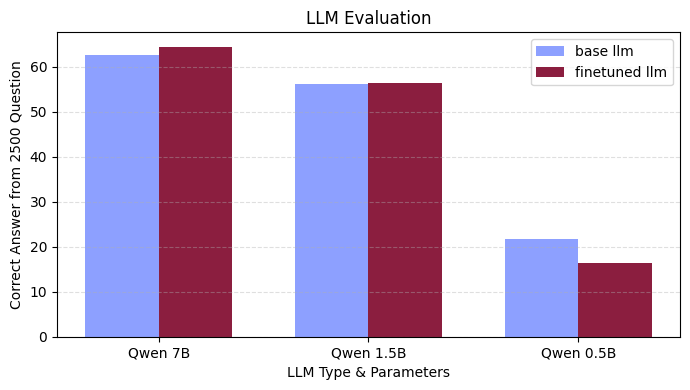

In [10]:
labels = ['Qwen 7B', 'Qwen 1.5B', 'Qwen 0.5B']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, llm_result_base, width=width,
        color='#8da0ff', label='base llm')

plt.bar(x + width/2, llm_result_finetuned, width=width,
        color='#8b1e3f', label='finetuned llm')

plt.xlabel("LLM Type & Parameters")
plt.ylabel("Correct Answer from 2500 Question")
plt.title("LLM Evaluation")

plt.legend()
plt.xticks(x, labels)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()